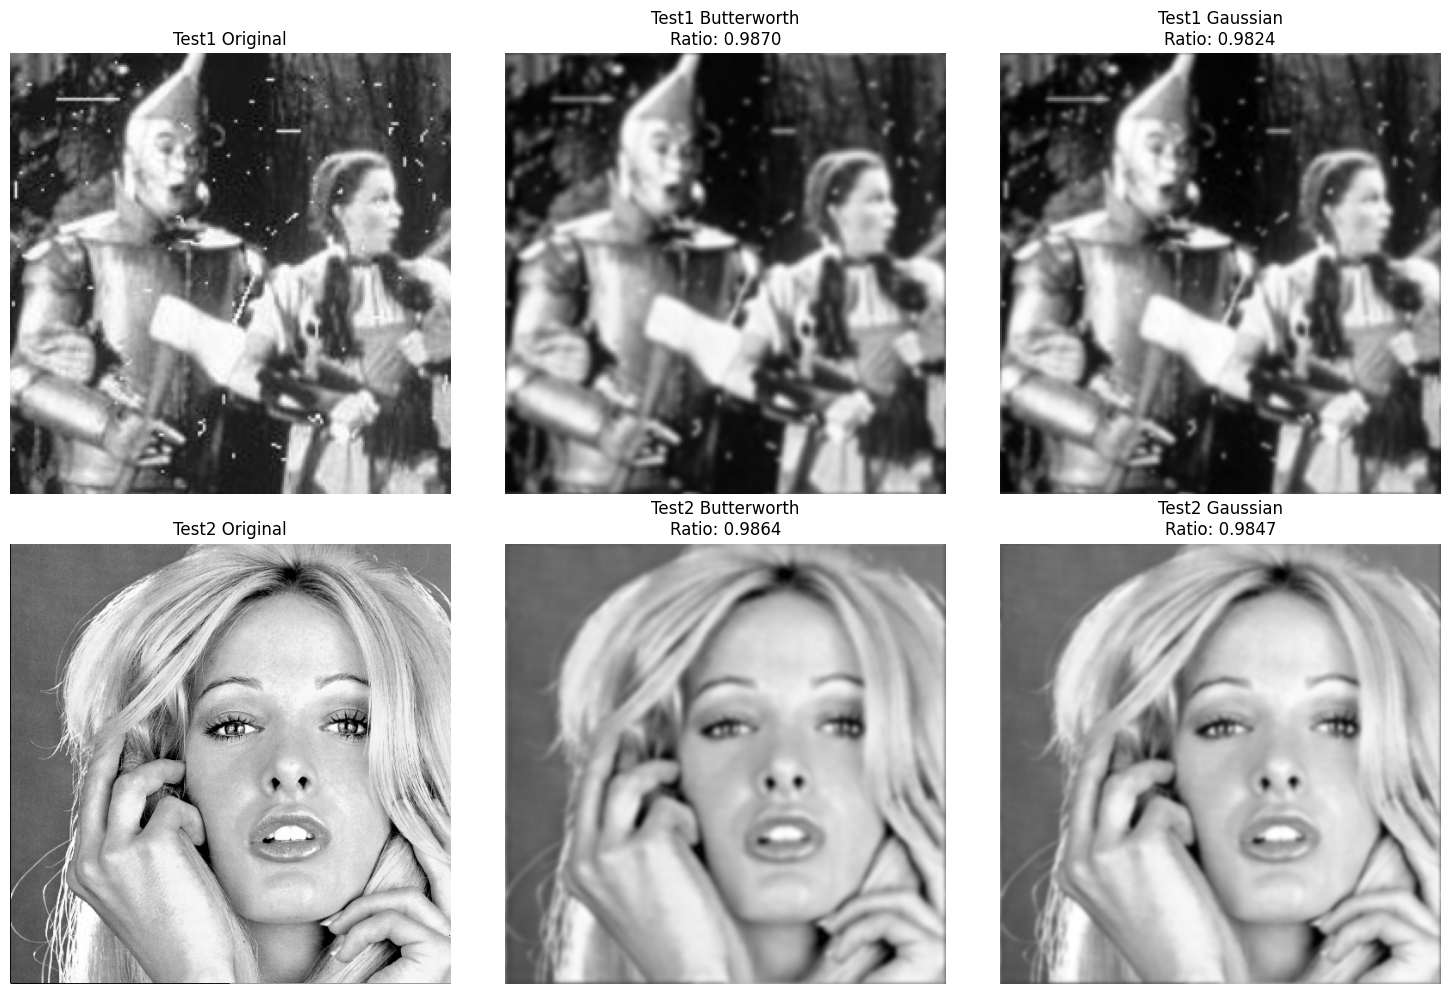

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_task1(image_path, D0, n=2):
    img = cv2.imread(image_path, 0)
    F = np.fft.fftshift(np.fft.fft2(img))
    M, N = img.shape
    
    # 距离矩阵与滤波器
    u, v = np.meshgrid(np.arange(M) - M//2, np.arange(N) - N//2, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    H_bt = 1 / (1 + (D / D0)**(2 * n))
    H_gs = np.exp(-(D**2) / (2 * (D0**2)))
    
    # 滤波处理
    G_bt = F * H_bt
    G_gs = F * H_gs
    
    # 逆变换回空域
    out_bt = np.abs(np.fft.ifft2(np.fft.ifftshift(G_bt)))
    out_gs = np.abs(np.fft.ifft2(np.fft.ifftshift(G_gs)))
    
    # 计算功率谱比 
    orig_pwr = np.sum(np.abs(F)**2)
    bt_pwr = np.sum(np.abs(G_bt)**2)
    gs_pwr = np.sum(np.abs(G_gs)**2)
    
    ratio_bt = bt_pwr / orig_pwr
    ratio_gs = gs_pwr / orig_pwr
    
    return img, out_bt, out_gs, ratio_bt, ratio_gs

# 执行处理
res1 = process_task1('test1.pgm', D0=40) # 假设半径40
res2 = process_task1('test2.tif', D0=40)

# 绘图展示 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：Test 1
axes[0,0].imshow(res1[0], cmap='gray'); axes[0,0].set_title('Test1 Original')
axes[0,1].imshow(res1[1], cmap='gray'); axes[0,1].set_title(f'Test1 Butterworth\nRatio: {res1[3]:.4f}')
axes[0,2].imshow(res1[2], cmap='gray'); axes[0,2].set_title(f'Test1 Gaussian\nRatio: {res1[4]:.4f}')

# 第二行：Test 2
axes[1,0].imshow(res2[0], cmap='gray'); axes[1,0].set_title('Test2 Original')
axes[1,1].imshow(res2[1], cmap='gray'); axes[1,1].set_title(f'Test2 Butterworth\nRatio: {res2[3]:.4f}')
axes[1,2].imshow(res2[2], cmap='gray'); axes[1,2].set_title(f'Test2 Gaussian\nRatio: {res2[4]:.4f}')

for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_task1(image_path, D0, n=2):
    img = cv2.imread(image_path, 0)
    F = np.fft.fftshift(np.fft.fft2(img))
    M, N = img.shape
    
    # 距离矩阵与滤波器
    u, v = np.meshgrid(np.arange(M) - M//2, np.arange(N) - N//2, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    H_bt = 1 / (1 + (D / D0)**(2 * n))
    H_gs = np.exp(-(D**2) / (2 * (D0**2)))
    
    # 滤波处理
    G_bt = F * H_bt
    G_gs = F * H_gs
    
    # 逆变换回空域
    out_bt = np.abs(np.fft.ifft2(np.fft.ifftshift(G_bt)))
    out_gs = np.abs(np.fft.ifft2(np.fft.ifftshift(G_gs)))
    
    # 计算功率谱比 
    orig_pwr = np.sum(np.abs(F)**2)
    bt_pwr = np.sum(np.abs(G_bt)**2)
    gs_pwr = np.sum(np.abs(G_gs)**2)
    
    ratio_bt = bt_pwr / orig_pwr
    ratio_gs = gs_pwr / orig_pwr
    
    return img, out_bt, out_gs, ratio_bt, ratio_gs

# 执行处理
res1 = process_task1('test1.pgm', D0=40) # 假设半径40
res2 = process_task1('test2.tif', D0=40)

# 绘图展示 
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：Test 1
axes[0,0].imshow(res1[0], cmap='gray'); axes[0,0].set_title('Test1 Original')
axes[0,1].imshow(res1[1], cmap='gray'); axes[0,1].set_title(f'Test1 Butterworth\nRatio: {res1[3]:.4f}')
axes[0,2].imshow(res1[2], cmap='gray'); axes[0,2].set_title(f'Test1 Gaussian\nRatio: {res1[4]:.4f}')

# 第二行：Test 2
axes[1,0].imshow(res2[0], cmap='gray'); axes[1,0].set_title('Test2 Original')
axes[1,1].imshow(res2[1], cmap='gray'); axes[1,1].set_title(f'Test2 Butterworth\nRatio: {res2[3]:.4f}')
axes[1,2].imshow(res2[2], cmap='gray'); axes[1,2].set_title(f'Test2 Gaussian\nRatio: {res2[4]:.4f}')

for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.savefig('report_assets/task1_lowpass.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_high_pass(image_path, D0, n=2):
    img = cv2.imread(image_path, 0)
    M, N = img.shape
    F = np.fft.fftshift(np.fft.fft2(img))
    
    # 距离矩阵
    u, v = np.meshgrid(np.arange(M) - M//2, np.arange(N) - N//2, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # 设计高通滤波器 (避免除以0，在 D 中加入极小值 eps)
    eps = 1e-8
    H_bt_hp = 1 / (1 + (D0 / (D + eps))**(2 * n))
    H_gs_hp = 1 - np.exp(-(D**2) / (2 * (D0**2)))
    
    # 滤波
    G_bt = F * H_bt_hp
    G_gs = F * H_gs_hp
    
    # 逆变换 (高通结果通常需要线性拉伸以便观察，这里取绝对值)
    out_bt = np.abs(np.fft.ifft2(np.fft.ifftshift(G_bt)))
    out_gs = np.abs(np.fft.ifft2(np.fft.ifftshift(G_gs)))
    
    # 计算功率谱比
    orig_pwr = np.sum(np.abs(F)**2)
    ratio_bt = np.sum(np.abs(G_bt)**2) / orig_pwr
    ratio_gs = np.sum(np.abs(G_gs)**2) / orig_pwr
    
    return img, out_bt, out_gs, ratio_bt, ratio_gs

# 高通滤波
res3 = process_high_pass('test3_corrupt.pgm', D0=20)
res4 = process_high_pass('test4.tif', D0=20)

# 绘图展示
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：Test 3
axes[0,0].imshow(res3[0], cmap='gray'); axes[0,0].set_title('Test3 Original')
axes[0,1].imshow(res3[1], cmap='gray'); axes[0,1].set_title(f'Test3 Butterworth HP\nRatio: {res3[3]:.4f}')
axes[0,2].imshow(res3[2], cmap='gray'); axes[0,2].set_title(f'Test3 Gaussian HP\nRatio: {res3[4]:.4f}')

# 第二行：Test 4
axes[1,0].imshow(res4[0], cmap='gray'); axes[1,0].set_title('Test4 Original')
axes[1,1].imshow(res4[1], cmap='gray'); axes[1,1].set_title(f'Test4 Butterworth HP\nRatio: {res4[3]:.4f}')
axes[1,2].imshow(res4[2], cmap='gray'); axes[1,2].set_title(f'Test4 Gaussian HP\nRatio: {res4[4]:.4f}')

for ax in axes.ravel(): ax.axis('off')
plt.tight_layout()
plt.savefig('report_assets/task2_highpass.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def process_task3(image_path, D0=30, k=1.0):
    img = cv2.imread(image_path, 0).astype(float)
    M, N = img.shape
    F = np.fft.fftshift(np.fft.fft2(img))
    
    u, v = np.meshgrid(np.arange(M) - M//2, np.arange(N) - N//2, indexing='ij')
    D = np.sqrt(u**2 + v**2)
    
    # 频域拉普拉斯 
    H_lap = -(D**2)
    G_lap = F * H_lap
    out_lap = np.real(np.fft.ifft2(np.fft.ifftshift(G_lap)))
    # 拉普拉斯结果通常需要缩放回 0-255
    out_lap = cv2.normalize(out_lap, None, 0, 255, cv2.NORM_MINMAX)
    
    # Unmasking 
    H_lp = np.exp(-(D**2) / (2 * (D0**2)))
    H_mask = 1 - H_lp  # 高频部分
    H_unmask = 1 + k * H_mask
    
    G_unmask = F * H_unmask
    out_unmask = np.real(np.fft.ifft2(np.fft.ifftshift(G_unmask)))
    out_unmask = cv2.normalize(out_unmask, None, 0, 255, cv2.NORM_MINMAX)
    
    return img.astype(np.uint8), out_lap.astype(np.uint8), out_unmask.astype(np.uint8)

# 处理 test3 和 test4
res3 = process_task3('test3_corrupt.pgm')
res4 = process_task3('test4.tif')

# 绘图展示
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

titles = ['Original', 'Laplacian (High Pass)', 'Unmasking (Enhanced)']
for i, res in enumerate([res3, res4]):
    for j in range(3):
        axes[i, j].imshow(res[j], cmap='gray')
        axes[i, j].set_title(f'Test{i+3} {titles[j]}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.savefig('report_assets/task3_other_hp.png', dpi=150, bbox_inches='tight')
plt.show()